# Stage 3 — אימון מודל לניקוי שעון אנלוגי

בשלב הזה נאמן מודל שמקבל תמונה של שעון אנלוגי עם מחוגים, ומחזיר תמונה של אותו שעון בלי מחוגים.

זו משימת Image-to-Image:

Input:
Analog clock with hands

Target:
Analog clean clock without hands

In [46]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from sklearn.model_selection import train_test_split

## הגדרות בסיס ונתיבים

נגדיר את מיקום הדאטה, גודל Batch, מספר Epochs, וקביעה האם האימון ירוץ על GPU או CPU.

In [47]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"
LABELS_PATH = DATA_DIR / "labels.csv"

BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Labels exists:", LABELS_PATH.exists())

Using device: cpu
Labels exists: True


## טעינת labels.csv

נטען את קובץ התוויות שיצרנו בשלב הדאטה.  
כאן נשתמש בעמודות:

- analog_with_hands_path
- analog_clean_path

In [48]:
df = pd.read_csv(LABELS_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 7)


,sample_id,digital_image_path,analog_with_hands_path,analog_clean_path,hour,minute,second
0,0,clock_project\data\digital\digital_00000.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,15,38,21
1,1,clock_project\data\digital\digital_00001.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,1,8,27
2,2,clock_project\data\digital\digital_00002.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,5,5,2
3,3,clock_project\data\digital\digital_00003.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,9,7,39
4,4,clock_project\data\digital\digital_00004.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,8,3,48


## חלוקה ל־Train ו־Validation

נחלק את הדאטה ל־80% אימון ו־20% בדיקה.

In [49]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 800
Validation size: 200


## Transform לתמונות

כאן נגדיר איך התמונות ייכנסו למודל.

גם תמונת הקלט וגם תמונת היעד יהיו בגודל 224x224 ויומרו ל־Tensor.

In [50]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## Dataset Class

ניצור Dataset שמחזיר זוג תמונות:

1. input_image — שעון אנלוגי עם מחוגים  
2. target_image — אותו שעון בלי מחוגים  

המודל ילמד להפוך את input ל־target.

In [51]:
class AnalogCleanerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        input_image = Image.open(row["analog_with_hands_path"]).convert("RGB")
        target_image = Image.open(row["analog_clean_path"]).convert("RGB")

        if self.transform:
            input_image = self.transform(input_image)
            target_image = self.transform(target_image)

        return input_image, target_image

## DataLoaders

ניצור DataLoader עבור train ועבור validation.

In [52]:
train_dataset = AnalogCleanerDataset(train_df, transform=transform)
val_dataset = AnalogCleanerDataset(val_df, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders ready")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

DataLoaders ready
Train batches: 50
Validation batches: 13


In [53]:
inputs, targets = next(iter(train_loader))

print("Input shape:", inputs.shape)
print("Target shape:", targets.shape)

Input shape: torch.Size([16, 3, 224, 224])
Target shape: torch.Size([16, 3, 224, 224])


## בניית המודל

נשתמש ב־AutoEncoder פשוט.

המודל יקבל:

שעון אנלוגי עם מחוגים

ויחזיר:

אותו שעון בלי מחוגים

בהמשך אפשר לשדרג ל־U-Net, אבל כרגע נתחיל בגרסה יציבה ופשוטה.

In [54]:
class AnalogCleanerAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 3,
                kernel_size=2,
                stride=2
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [55]:
EPOCHS = 30

model = AnalogCleanerUNet().to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("U-Net model ready")

U-Net model ready


In [56]:
class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class AnalogCleanerUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = UNetBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = UNetBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = UNetBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = UNetBlock(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = UNetBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = UNetBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = UNetBlock(64, 32)

        self.final = nn.Conv2d(32, 3, kernel_size=1)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        enc1 = self.enc1(x)
        x = self.pool1(enc1)

        enc2 = self.enc2(x)
        x = self.pool2(enc2)

        enc3 = self.enc3(x)
        x = self.pool3(enc3)

        x = self.bottleneck(x)

        x = self.up3(x)
        x = torch.cat([x, enc3], dim=1)
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)

        x = self.final(x)
        x = self.output_activation(x)

        return x

## אימון המודל

נאמן את המודל להשוות בין:

- הפלט שהוא מייצר
- תמונת היעד הנקייה

המדד הוא MSE Loss — כלומר טעות ממוצעת בין הפיקסלים.

In [57]:
history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for input_images, target_images in train_loader:
        input_images = input_images.to(DEVICE)
        target_images = target_images.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(input_images)
        loss = criterion(outputs, target_images)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for input_images, target_images in val_loader:
            input_images = input_images.to(DEVICE)
            target_images = target_images.to(DEVICE)

            outputs = model(input_images)
            loss = criterion(outputs, target_images)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch 1/30 | Train Loss: 0.065877 | Val Loss: 0.027979
Epoch 2/30 | Train Loss: 0.026531 | Val Loss: 0.025252
Epoch 3/30 | Train Loss: 0.025498 | Val Loss: 0.024295
Epoch 4/30 | Train Loss: 0.024745 | Val Loss: 0.023580
Epoch 5/30 | Train Loss: 0.024725 | Val Loss: 0.023534
Epoch 6/30 | Train Loss: 0.024094 | Val Loss: 0.023056
Epoch 7/30 | Train Loss: 0.023904 | Val Loss: 0.023099
Epoch 8/30 | Train Loss: 0.023974 | Val Loss: 0.023550
Epoch 9/30 | Train Loss: 0.023804 | Val Loss: 0.023207
Epoch 10/30 | Train Loss: 0.023574 | Val Loss: 0.022564
Epoch 11/30 | Train Loss: 0.023478 | Val Loss: 0.023276
Epoch 12/30 | Train Loss: 0.023575 | Val Loss: 0.023092
Epoch 13/30 | Train Loss: 0.023554 | Val Loss: 0.023605
Epoch 14/30 | Train Loss: 0.023307 | Val Loss: 0.022535
Epoch 15/30 | Train Loss: 0.023390 | Val Loss: 0.022290
Epoch 16/30 | Train Loss: 0.023427 | Val Loss: 0.022516
Epoch 17/30 | Train Loss: 0.023299 | Val Loss: 0.022369
Epoch 18/30 | Train Loss: 0.023421 | Val Loss: 0.022371
E

## שמירת המודל והיסטוריית האימון

נשמור את המודל המאומן ואת תוצאות האימון לקבצים.

In [58]:
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "analog_cleaner_unet.pth"
HISTORY_PATH = RESULTS_DIR / "analog_cleaner_unet_training_history.csv"

torch.save(model.state_dict(), MODEL_PATH)

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print("U-Net model saved to:", MODEL_PATH)
print("U-Net history saved to:", HISTORY_PATH)

history_df

U-Net model saved to: clock_project\models\analog_cleaner_unet.pth
U-Net history saved to: clock_project\results\analog_cleaner_unet_training_history.csv


,train_loss,val_loss
0,0.065877,0.027979
1,0.026531,0.025252
2,0.025498,0.024295
3,0.024745,0.023580
4,0.024725,0.023534
5,0.024094,0.023056
6,0.023904,0.023099
7,0.023974,0.023550
8,0.023804,0.023207
9,0.023574,0.022564


## גרף Loss

נציג את ה־Train Loss ואת ה־Validation Loss לאורך האימון.

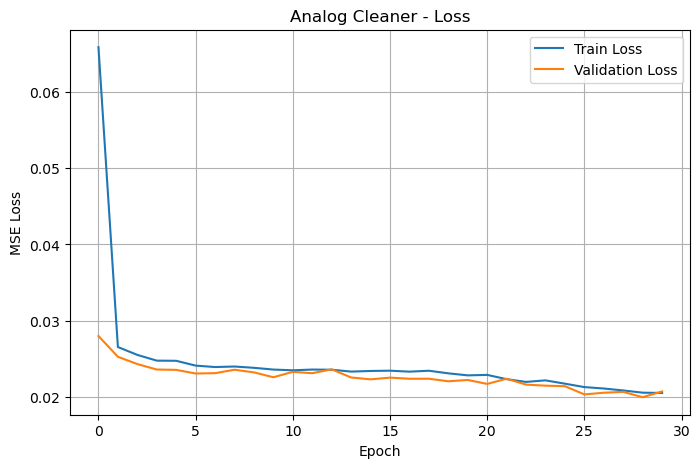

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Analog Cleaner - Loss")
plt.legend()
plt.grid(True)
plt.show()

## בדיקה ויזואלית

נבדוק על דוגמה מה־validation:

- Input — שעון עם מחוגים
- Prediction — הפלט של המודל
- Target — השעון הנקי האמיתי

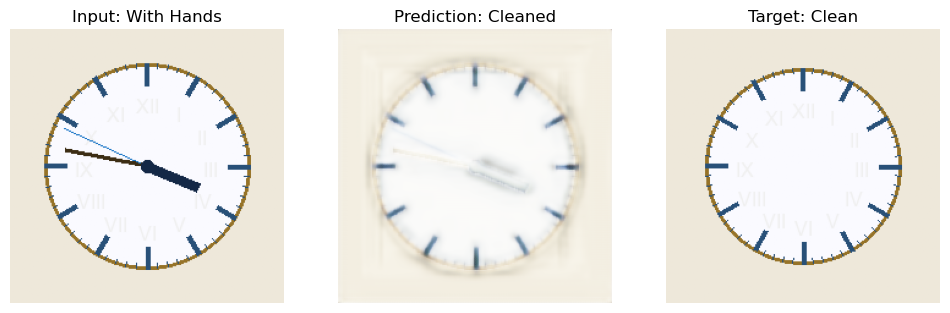

In [60]:
model.eval()

input_image, target_image = val_dataset[0]

input_batch = input_image.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    output_image = model(input_batch)

output_image = output_image.squeeze(0).cpu()

def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor.permute(1, 2, 0)
    tensor = torch.clamp(tensor, 0, 1)
    return tensor.numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(tensor_to_image(input_image))
plt.title("Input: With Hands")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(tensor_to_image(output_image))
plt.title("Prediction: Cleaned")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(tensor_to_image(target_image))
plt.title("Target: Clean")
plt.axis("off")

plt.show()